# Tutorial 2 - Identifying ghost structures: channels, cycles, networks

In Koch et al. 2024 we discovered that multiple ghosts can be connected in phase space to form what we termed *ghost channels* and *ghost cycles* akin to heteroclinic connections between saddles forming channels and cycles. More recently, in Koch & Nandan 2026 we found this can be taken even further to complex *ghost networks* in phase space.

PyGhostID features a simple function to reconstruct these ghost structures from trajectories: `ghost_connections`. All you need is a list of one or more `ghostSeq`s and the function will return an adjacency matrix that represents how the ghosts identified in the system are connected to each other. In addition, you can use the `draw_network` function (which makes use of [NetworkX](https://networkx.org/)) to conveniently visualize the identified structures.

A good way to identify ghost structures is to use PyGhostIDs `ghostID_phaseSpaceSample` function, which automatically samples many trajectories within a selected area of phase space, searches for ghosts and unifies their IDs accross samples.

Below you will find three simple examples which illustrate these functionalities.

## Example 1

In our first example, we will identify and visualize a ghost channel between two ghosts in the model by [Wunderling et al](https://esd.copernicus.org/articles/12/601/2021/) for two mutually coupled climate tipping elements. As in previous tutorials, we run a simulation and identify ghosts from the trajectory:

In [1]:
# imports
import numpy as np
import jax.numpy as jnp
from scipy.integrate import solve_ivp
import PyGhostID as gid
import matplotlib.pyplot as plt

#define the model
def wunderling_model(t, Z, para):
    Z = jnp.asarray(Z, dtype=jnp.float32)

    d,GMT,Tcrits,Taus,mat_inter=para

    intrinsic = -Z**3 + Z + np.sqrt(4/27)*GMT/Tcrits
    coupling = d/10* mat_inter @ (Z + 1)

    # Total derivative
    dZdt = (intrinsic+coupling)/Taus

    return jnp.array(dZdt) 

# Set parameters
d = 0.15
GMT = 1.61
Tcrits = np.array([1.5,1.6]) 
Taus = np.array([100,1000])
interactions=np.array([[0,1],
                    [1,0]])

parameters_Wunderling = [d,GMT,Tcrits,Taus,interactions]

dt = 5
timesteps = np.linspace(0,1e5,int(1e5/dt))

# simulate trajectory 
sol = solve_ivp(wunderling_model, (0, 1e5), [-1.5,-1.2], t_eval=timesteps, args=(parameters_Wunderling,),method='RK45',rtol=1e-4,atol=1e-6)


# identify ghosts
Trj=sol.y.T
ghostSeq = gid.ghostID(wunderling_model,parameters_Wunderling,dt,Trj,0.03,peak_kwargs={"prominence":2,"width":20*dt})

Next, we determine the ghost connections and visualize them:

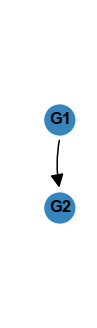

In [2]:
# identify ghost connections
ghostConnections, labels = gid.ghost_connections([ghostSeq])

# plot ghost connections
plt.figure(figsize=(1,4))
node_colors = ["C0"]*len(ghostConnections)
gid.draw_network(ghostConnections, node_colors, labels, layout="hierarchical",rankdir="TB",node_size=550,label_font_size=12)
plt.gca().margins(1.25)
plt.axis("off");

## Example 2

In the following example we're gonna identify a 3-ghost cycle in a simple GRN model from [Farjami et al.](https://doi.org/10.1098/rsif.2021.0442) which is organized close to three co-occuring SNIC bifurcations that give rise to three ghosts on the limit cycle.  We run a simulation and identify ghosts from the trajectory:

In [3]:
def farjami_etal(t,x,p):
  
    g = p
    
    g1 = g; g2 = g; g3 = g
    
    b1 = 1e-5; b2 = 1e-5; b3 = 1e-5
    alpha1 = 9; alpha2 = 9; alpha3 = 9
    beta1 = 0.1; beta2 = 0.1; beta3 = 0.1
    h = 3
    d1 = 0.2; d2 = 0.2; d3 = 0.2
    
    dx1 = b1 + g1 / ((1+alpha1*(x[1]**h))*(1+beta1*(x[2]**h))) - d1*x[0]
    dx2 = b2 + g2 / ((1+alpha2*(x[2]**h))*(1+beta2*(x[0]**h))) - d2*x[1]
    dx3 = b3 + g3 / ((1+alpha3*(x[0]**h))*(1+beta3*(x[1]**h))) - d3*x[2]
    
    return jnp.array([dx1, dx2, dx3])

# set parameters
g_Farjami=1.5

# set time parameters
t_end = 800
dt = 0.1
timesteps = np.linspace(0,t_end,int(t_end/dt))

# simulate trajectory 
ICs = [0.6,0.8,0.8]
sol = solve_ivp(farjami_etal, (0, t_end), ICs, t_eval=timesteps, args=(g_Farjami,),method='RK45',rtol=1e-6,atol=1e-6)

# run ghostID
Trj_farjami=sol.y.T
ghostSeq_farjami = gid.ghostID(farjami_etal,g_Farjami,dt,Trj_farjami,eigval_NN_sorting=True,peak_kwargs={"prominence":5,"width":200,"distance":20})

Identifying and visualizing the ghost connections, we can see that ghostID found three ghosts that are connected to each other to form a cycle:

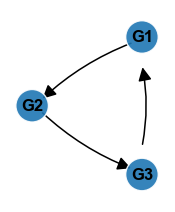

In [4]:
# identify ghost connections
ghostConnections, labels = gid.ghost_connections([ghostSeq_farjami])

# plot ghost connections
plt.figure(figsize=(2,2.5))
node_colors = ["C0"]*len(ghostConnections)
gid.draw_network(ghostConnections, node_colors, labels, layout="hierarchical",rankdir="TB",node_size=550,label_font_size=12)
plt.gca().margins(.2)
plt.axis("off");

# Example 3

In our last example, we're gonna look at a ghost network emerging from a generic GRN with random topology as in Figure 6 from [Koch & Nandan 2026](https://arxiv.org/abs/2604.05194).

First, we need to define the topology of the GRN, i.e., we need an adjacency matrix that we will generate using the NetworkX package. Let's generate a small random network with eight nodes:

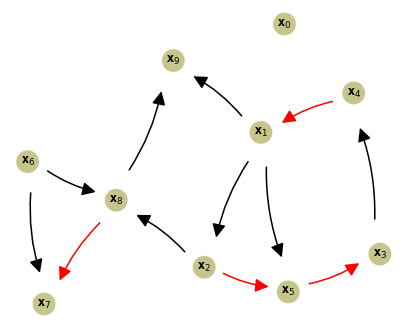

In [5]:
import networkx as nx

n = 10

# for seed in range(1,30):

seed = 21 #14, 21, 23
rng = np.random.default_rng(seed)
np.random.seed(seed)

G = nx.erdos_renyi_graph(n,0.15,directed=True,seed=seed)
A = nx.to_numpy_array(G)

p_inhibitory = 0.5
# introduce inhibitory links
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        if A[i, j] == 1:
            if rng.random() < p_inhibitory:
                A[i, j] = -1


node_colors = [(0.75, 0.75, 0.5, 0.8)] * n
node_labels = [f"x$_{{{i}}}$" for i in range(n)]

plt.figure(figsize=(5,4))
gid.draw_network(A, node_colors, node_labels, layout="neato",node_size=300,label_font_size=9,graphviz_args=f"-Gepsilon=.0001 -Goverlap=false -Gstart=5 -splines=true")
plt.axis("off");



Next, we need to identify the ghosts embedded in the dynamics of this networks. This time, however, we will use PyGhostID's `ghostID_phaseSpaceSample` function, which allows us to identify ghosts from sampling many trajectories simultaneously while also exploiting multithreading to speed up the process:

In [6]:
# define the model
def GRN_net(t, x, para):
    a, b, K, Ka, Ki, A = para
    x = jnp.asarray(x, dtype=jnp.float32)

    # Nonlinear transforms
    x2 = x**2
    f_self = a * x2 / (x2 + K**2)                 # shape (N,)
    f_exc  = x2 / (x2 + Ka**2)                    # shape (N,)
    f_inh  = Ki**2 / (x2 + Ki**2)                 # shape (N,)

    # Masks
    exc_mask = (A == 1).astype(float)             # shape (N,N)
    inh_mask = (A == -1).astype(float)            # shape (N,N)

    # Excitatory sum
    exc = b * (exc_mask @ f_exc)                  # shape (N,)

    # Inhibitory product
    inh = jnp.exp(inh_mask @ jnp.log(f_inh))        # shape (N,)

    # Final ODE
    xdot = (f_self + exc) * inh - x

    return jnp.asarray(xdot)

# Run ghostID on phase space samples
parameters_GRN_net = [0.998,0.25,0.5,0.5,0.5,A]
dt = 0.1
t_end = 800
timesteps = np.linspace(0,t_end,int(t_end/dt))

result_pss = gid.ghostID_phaseSpaceSample(GRN_net,parameters_GRN_net,0,t_end,dt,
                                        [np.linspace(0,1,10) for i in range(n)],n_samples=100,seed=1,
                                        peak_kwargs={"prominence":2,"width":50*dt},display_warnings=False,epsilon_gid=0.015,eigval_NN_sorting=True,epsilon_SN_ghosts=0.5,epsilon_unify=0.75)

[ghostID_phaseSpaceSample] Running with threads (11 workers)


Processing ICs: 100%|██████████| 100/100 [04:08<00:00,  2.49s/IC]


Identifying and visualizing the ghost connections, we can see that ghostID found a network of ghosts. Additionally, we colored the nodes according dimension of the identified ghosts.

C:\Users\dkoch\AppData\Local\Temp\ipykernel_17800\3732929772.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('spring_r', maxDim+1)


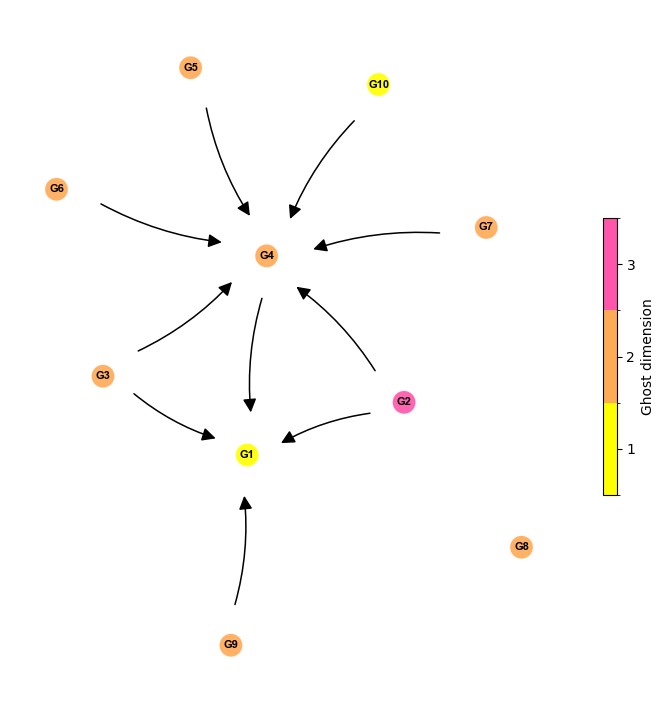

: 

In [ ]:
import matplotlib.colors as mcolors
M, M_labels = gid.ghost_connections(result_pss)
unique_ghosts = gid.unique_ghosts(result_pss)

dimensions = [g["dimension"] for g in unique_ghosts]
maxDim = max(dimensions)
cmap = plt.cm.get_cmap('spring_r', maxDim+1)
nodeColors = [cmap(dim-1) for dim in dimensions]
plt.figure(figsize=(9,9))
gid.draw_network(M, nodeColors, M_labels, layout="neato",node_size=300,label_font_size=8,graphviz_args=f"-Gepsilon=.000001 -Goverlap=true -Gstart=9 -splines=true") #Gstart 2
boundaries = np.arange(maxDim + 1) - 0.5
norm = mcolors.BoundaryNorm(boundaries, ncolors=maxDim)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', shrink=0.4)
cbar.set_ticks(np.arange(maxDim))
cbar.set_ticklabels([f'{i+1}' for i in range(maxDim)])
cbar.set_label('Ghost dimension')
plt.axis("off")
plt.gca().margins(0.1)